# PT3S
Use SIR 3S Modeldata and SIR 3S Results in pure Python.

With pandas, matplotlib and others.

For documentation, test, verification, analysis, reporting, prototyping, play.

## Install Python

Python 3.7 (64-bit) [PTVS 16.6.20100.1-16.0]

## Install PT3S to site-packages

In [1]:
### ggf. Rechte erforderlich:  
### entweder in PowerShell: Start-Process powershell -Verb runAs
### oder RMT WindowsSymbol: Windows PowerShell (Administrator)
### dann (ohne ! in PowerShell auf pip-Verz.):
###!pip uninstall --yes PT3S
###!pip install PT3S --no-cache-dir

## OR use local PT3S under Development

In [2]:
###!pip install -e .

## Logging

In [3]:
import logging
import os
logger = logging.getLogger('PT3S')  

logFileName= r"PT3S.log" 

loglevel = logging.DEBUG
logging.basicConfig(filename=logFileName
                        ,filemode='w'
                        ,level=loglevel
                        ,format="%(asctime)s ; %(name)-60s ; %(levelname)-7s ; %(message)s")    

fileHandler = logging.FileHandler(logFileName)     

logger.addHandler(fileHandler)

consoleHandler = logging.StreamHandler()
consoleHandler.setFormatter(logging.Formatter("%(levelname)-7s ; %(message)s"))
consoleHandler.setLevel(logging.INFO)
logger.addHandler(consoleHandler)

## about from PT3S ... import ... and pip install -e .

In [4]:
#%pwd

In [5]:
# works only if pip install -e .is NOT active:
###from PT3S import Mx,Xm,Rm
# or if subdir is PT3S
#%cd -q ..
# ...
#%cd -q PT3S 

In [6]:
# if pip install -e .IS active
# the local modules can be imported with:
import Mx, Xm, Rm
# if %pwd is local devdir

In [7]:
import doctest
"""
>>> import pandas as pd
>>> pd.__version__
'1.0.4'
"""
doctest.testmod()

TestResults(failed=0, attempted=2)

# ggf. Tests

## Modultests

* die Modultests (-m 1) gehen teilweise von einem definierten "leeren" Ausgangszustand aus: Relikte aus alten Testläufen sollten daher gelöscht werden (-t before), wenn die Modultests vollständig ohne Fehler durchlaufen sollen 
* die Modultests hinterlassen teilweise "Überbleibsel", die explizit gelöscht werden sollten (-t after ==> -t both)
* es müssen nur die Modelle (-w ...) behandelt werden (vorher bzw. nachher aufräumen), die in den Modultests auch verwendet werden
* es werden alle Modultests durchgeführt

nachfolgende Tests erzeugen (trotz -q) auch bei fehlerfreiem Durchlauf eine Ausgabe im Notebook

.
----------------------------------------------------------------------
Ran 1 test in 6.523s

OK
.
----------------------------------------------------------------------
Ran 1 test in 16.002s

OK
F
FAIL: Rm ()
Doctest: Rm
----------------------------------------------------------------------
Traceback (most recent call last):
  File "c:\program files (x86)\microsoft visual studio\shared\python37_64\lib\doctest.py", line 2196, in runTest
    raise self.failureException(self.format_failure(new.getvalue()))
AssertionError: Failed doctest test for Rm
  File "C:\Users\wolters.3S\source\repos\PT3S\Rm.py", line 0, in Rm

----------------------------------------------------------------------
File "C:\Users\wolters.3S\source\repos\PT3S\Rm.py", line 79, in Rm
Failed example:
    print(pFWVB[['Measure','MCategory','GCategory','VIC']].to_string(formatters={'Measure':f}))
Expected:
       Measure MCategory  GCategory   VIC
    0  0.80971       Top  BLNZ1u5u7   NaN
    1  0.66692    Middle         

**********************************************************************
File "C:\Users\wolters.3S\source\repos\PT3S\Rm.py", line 79, in Rm
Failed example:
    print(pFWVB[['Measure','MCategory','GCategory','VIC']].to_string(formatters={'Measure':f}))
Expected:
       Measure MCategory  GCategory   VIC
    0  0.80971       Top  BLNZ1u5u7   NaN
    1  0.66692    Middle              NaN
    2  0.66043    Middle  BLNZ1u5u7   NaN
    3  0.65551    Bottom  BLNZ1u5u7  VIC1
    4  0.68548    Middle              NaN
Got:
       Measure MCategory  GCategory   VIC
    0  0.80992       Top  BLNZ1u5u7   NaN
    1  0.66711    Middle              NaN
    2  0.66061    Middle  BLNZ1u5u7   NaN
    3  0.65569    Bottom  BLNZ1u5u7  VIC1
    4  0.68566    Middle              NaN


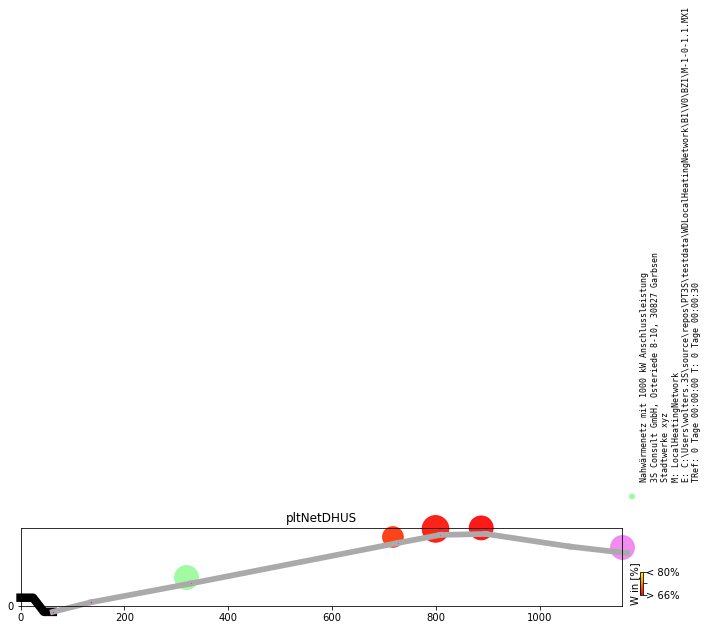

In [8]:
%run test.py -l -q -m 1 -t both \
-w OneLPipe -w LocalHeatingNetwork -w GPipe -w GPipes -w TinyWDN

## Singeltests

* es müssen nur die Modelle (-w ...) behandelt werden, die in den Singletests auch verwendet werden
* vor Singletests könnten die Modultests durchgeführt werden: nachfolgend sind diese ausgeschaltet (-m 0)
* Singletests hinterlassen, so sie nicht selbst aufräumen, "Überbleibsel", die explizit gelöscht werden sollten (-t after)
* Singletests erfahren im Gegensatz zu Modultests ein explizites MockUp außerhalb des eigentlichen Tests; d.h. die Tests beginnen mit "fertigen" Objekten bzw. können zumindest so beginnen; bei Modultests hingegen erfolgt das MockUp immer in der Testsequenz selbst 
* Details zum MockUp können mit -y (kein H5 lesen j/n) und -z (H5 schreiben j/n) angegeben werden
* es können nur die Singletest auf einmal ausgeführt werden, die mit demselben MockUp zurecht kommen
* MockUp hier: kein H5 lesen und kein H5-Schreiben: -y yes -z no 
* nur bei -z yes wird vor dem H5-Schreiben auch Xm.MxSync und .MxAdd durchgeführt
* -s spezifiziert Tests per regExp
* -x spezifiziert Test per regExp die aus der -s-Menge nicht durchzuführen sind

nachfolgende Tests erzeugen (wg. -q) nur bei fehlerfreiem Durchlauf _keine Ausgaben im Notebook

In [ ]:
%run test.py -l -q -m 0 \
-s Mx\. -s Xm\. \
-x Mx\.FromH5 \
-x Mx\.ToH5 \
-x Xm\.vKNOTexpEBES \
-x Xm\.vROHRexpEBES \
-x Xm\._vRUES -x Xm\._vRSLW -x Xm\._vRSTN -x Xm\._vRXXX -x Xm\._vREdges \
-x Xm\.MxAdd \
-t both -y yes -z no \
-w OneLPipe -w LocalHeatingNetwork -w GPipe -w GPipes -w TinyWDN

### reiner MockUp-Lauf

* es wird gar kein Test spezifiziert sondern ein reiner MockUp-Lauf
* geeignet z.B. wenn ein MockUp zeitaufwendig ist ...
* ... und ein bestimmter Singletest in einem Modul häufig wiederholt werden muss ...
* ... weil am getesteten Funktionsbereich gearbeitet wird
* MockUp hier: kein H5 lesen aber H5 schreiben: -y yes -z yes
* mit -u wird der reine MockUp-Lauf durchgeführt

nachfolgender Lauf erzeugt (wg. -q) bei fehlerfreiem Durchlauf _keine Ausgaben im Notebook

In [ ]:
# test_reinerMockUpLauf
%run test.py -l -q -m 0 -t before \
-u yes \
-y yes -z yes \
-w DHNetwork -w LocalHeatingNetwork -w GPipes 

 ### Singletest basierend auf diesem reinem MockUp-Lauf
 
 * Testläufe können mit H5 lesen (-y no) und kein H5 schreiben (-z no) am Schnellsten durchgeführt werden
 * Singletest und MockUp müssen zueinander passen (d.h. z.B. wenn ein Singletest mit "fertigen" Objekten beginnt müssen diese durch den MockUp bereitgestellt werden)
 * der Entwicklungsstand ebenfalls: die "fertigen" Objekte werden ja zuvor in einem (ggf. reinen MockUp-Lauf) erzeugt und als H5 abgespeichert; mit solchen Singletests kann daher nur gearbeitet werden wenn andere Codeteile entsprechend "durchlaufen"

In [ ]:
%run test.py -l -q -m 0 \
-s Xm\.vKNOTexpEBES \
-s Xm\.vROHRexpEBES \
-s Xm\._vRUES -s Xm\._vRSLW -s Xm\._vRSTN -s Xm\._vRXXX -s Xm\._vREdges \
-s Xm\.MxAdd \
-y no -z no \
-w DHNetwork -w LocalHeatingNetwork -w GPipes 

 ### weitere Beispiele für Singletests

Beispiel: durchführen eines einzelnen Tests in Modul Mx über Mx.py

das Testobjekt ist eine Klassen-freie Funktion, die kein Modell-MockUp benötigt

In [ ]:
%run Mx.py -l -q -m 0 -s getMicrosecondsFromRefTime 

Beispiel: durchführen eines einzelnen Tests in Modul Xm über Xm.py

das Testobjekt ist eine Klassen-Funktion, welche die angegebenen Modell-MockUps benötigt

In [ ]:
%run Xm.py -l -q -m 0 -s Xm\.constructShortestPathFromNodeList -t both -y yes -z no -w GPipes -w LocalHeatingNetwork

Beispiel: weitere Singletests

In [ ]:
%run Rm.py -l -q -m 0 \
-s pltMakeCategoricalColors \
-s pltMakeCategoricalCmap \
-s Rm\. \
-y no -z no \
-w DHNetwork

## Modultests mit anderen Daten

In [ ]:
%run test.py -l -q -m 1 -t both --testDir testdata11 

In [ ]:
%run test.py -l -q -m 1 -t both --testDir testdata10 

In [ ]:
%run test.py -l -q -m 1 -t both --testDir testdata09 --dotResolution NONE

# Modell und Ergebnisse laden und nutzen

In [ ]:
import pandas as pd
import numpy as np
import scipy
import networkx as nx

## Modell

In [ ]:
path='.'
xmlFile=os.path.join(path,'testdata\LocalHeatingNetwork.XML')
xm=Xm.Xm(xmlFile=xmlFile)

In [ ]:
vVBEL=xm.dataFrames['vVBEL']
vVBEL.filter(items=['BESCHREIBUNG','NAME_i','NAME_k','LAYR','L','D']).sort_index(level=1)

In [ ]:
vVBEL.dtypes

In [ ]:
[viewOrTable for viewOrTable in sorted(xm.dataFrames.keys())]

## Ergebnisse

In [ ]:
# Weg A um an Ergebnisse zu kommen: 
# Modell(-Views) um MX-Ergebnisse ergaenzen; MX-Ergebnissatz des Modells wird implizit gelesen und returned
mx=xm.MxSync()

In [ ]:
# Weg B um an Ergebnisse zu kommen:
# einen MX-Ergebnissatz voellig unabhaengig von einem Modell lesen
# z.B. den MX-Ergebnissatz des Modells ...
(wDir,modelDir,modelName,mx1File)=xm.getWDirModelDirModelName()  
# ... lesen
mx=Mx.Mx(mx1File=mx1File)

### Non-Vector

In [ ]:
mx.df.filter(items=['ALLG~~~4639827058859487185~SNAPSHOTTYPE','KNOT~V-L~~5736262931552588702~PH'])

In [ ]:
mx.df.filter(regex='^KNOT').filter(regex='PH$').plot()

### Vector

In [ ]:
timesReq=mx.df.index.tolist()
mxVecsFileData=mx.getMxsVecsFileData(timesReq)
for vecsFileResult in mxVecsFileData:
    print(vecsFileResult.index)

In [ ]:
vecsFileResult.filter(regex='^ROHR').filter(regex='^(?!.*VEC)')

In [ ]:
vecsFileResult.filter(regex='^KNOT')

### Vector: Aggregate
- TIME: MXS: SIR 3S t=0-Ergebnis als instat. AB (kein Aggregat) - implizit von _readMxsFile
- TMIN,TMAX: MXS: SIR 3S Min./Max. - implizit von _readMxsFile  
- or Aggregates from 2 Times: MIN,MAX,... - implizit von getVecAggs

In [ ]:
mx.dfVecAggs

## Modell und Ergebnis "synchronisieren"
- Bezuege herstellen zwischen einem Modell und einem Ergebnissatz (Stichworte mx2Idx, NAME123) 
- mx=xm.MxSync() synchronisiert implizit mit dem MX-Ergebnissatz des Modells (der MX-Satz wir dabei gelesen)
- xm.MxSync(mx=mx): explizite Synchronisation mit irgendeinem bereits gelesenen MX-Ergebnissatz

In [ ]:
xm.MxSync(mx=mx)

In [ ]:
vROHR=xm.dataFrames['vROHR']

In [ ]:
vROHR[['L','mx2NofPts','mx2Idx']]

## Modellsichten um Ergebnisse "ergänzen"
- die Modellsichten werden dabei um Ergebnisspalten ergänzt
- mx=xm.MxAdd() synchronisiert vorher implizit mit dem MX-Ergebnissatz des Modells (der MX-Satz wir dabei gelesen)
- mx=xm.MxAdd() ist somit der KUERZESTE Aurufweg nach dem Lesen eines Modells mit Modell+Ergebnissen weiterzuarbeiten
- xm.MxAdd(mx=mx): die Ergebnisse werden aus dem angegebenen MX-Satz entnommen
- ohne Zeitangabe ergänzt MxAdd das stationäre Ergebnis
- statt mit dem Ergebnis einer Szenariumzeit können die Modellsichten auch mit Ergebnisaggregaten über eine Zeitspanne ergänzt werden
- die ergänzten Ergebnisspalten "kumulieren nicht"; die Ergebnisspaltennamen sind nach jedem MxAdd-Aufruf gleich und gleich viele  

In [ ]:
xm.MxAdd(mx=mx)

### Vektorergebnisse

In [ ]:
vKNOT=xm.dataFrames['vKNOT']
vKNOT.dtypes

In [ ]:
vVBEL=xm.dataFrames['vVBEL']
vVBEL.filter(items=['NAME_i','NAME_k','Z_i','KNOT~*~*~*~PH_i','Q']).sort_values(['Q','KNOT~*~*~*~PH_i'], ascending=[1,0])

In [ ]:
vVBEL.dtypes

In [ ]:
vROHR=xm.dataFrames['vROHR']
vROHR.dtypes

In [ ]:
vFWVB=xm.dataFrames['vFWVB']
vFWVB.dtypes

### Rohrvektorergebnisse

In [ ]:
vROHRVecResults=xm.dataFrames['vROHRVecResults']
vROHRVecResults[['pk','mx2Idx','IptIdx','ROHR~*~*~*~SVEC','ROHR~*~*~*~ZVEC','ROHR~*~*~*~MVEC']]

## Schnitte

In [ ]:
vAGSN=xm.dataFrames['vAGSN']

In [ ]:
vAGSN.dtypes

In [ ]:
dfOneVL=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==1)]
dfOneVL[['OBJTYPE','x','P','Q']]

In [ ]:
dfOneRL=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==2)]
dfOneRL[['OBJTYPE','x','P','Q']]

In [ ]:
plt.plot(dfOneVL['x'],dfOneVL['Q']
         ,dfOneRL['x'],dfOneRL['Q'])

In [ ]:
plt.plot(dfOneVL['x'],dfOneVL['P']
         ,dfOneRL['x'],dfOneRL['P'])
plt.ylim((2.5, 5.5))   

In [ ]:
# SIR 3S MIN-Ergebnis lesen
xm.MxAdd(mx=mx,aggReq='TMIN')
vAGSN=xm.dataFrames['vAGSN']
dfOneVLTMIN=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==1)]

plt.plot(dfOneVL['x'],dfOneVL['P']
         ,dfOneRL['x'],dfOneRL['P']
         ,dfOneVL['x'],dfOneVLTMIN['P']         
        )
plt.ylim((2.5, 5.5))   

## Store in H5

In [ ]:
xm.ToH5()
mx.ToH5()
# next read will be faster because H5 is read instead of XML / MX if H5 is newer than XML / MX

In [ ]:
xm=Xm.Xm(xmlFile=xmlFile)

In [ ]:
mx=Mx.Mx(mx1File=mx1File)

In [ ]:
#xm?

In [ ]:
#mx?

# Rm Plot Beispiele

In [ ]:
rm=Rm.Rm(xm=xm,mx=mx)

## Bsp1: Prozentdarstellung - keine Klassen

In [ ]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                                  
                 pltTitle='pltNetDHUS: Bsp1: Prozentdarstellung - keine Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
    
                 ,pVICsDf=pd.DataFrame({'Kundenname': ['VIC1'],'Knotenname': ['V-K007']})
    
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                     
                   )
plt.show()

## Bsp2: Prozentdarstellung - Klassen

In [ ]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                   
                 pltTitle='pltNetDHUS: Bsp2: Prozentdarstellung - Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
    
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureCBFixedLimitHigh=0.80
                 ,pFWVBMeasureCBFixedLimitLow=0.66
                   )
plt.show()

## Bsp3: keine Prozentdarstellung - Klassen

In [ ]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(         
                 pltTitle='pltNetDHUS: Bsp3: keine Prozentdarstellung - Klassen'                   
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureInRefPerc=False  
                 ,pFWVBMeasure='FWVB~*~*~*~W' 
                 
                 ,pFWVBMeasureCBFixedLimitHigh=200.
                 ,pFWVBMeasureCBFixedLimitLow=130.
                   )
plt.show()

# NetworkX Beispiele

## hydraulisches Prozessmodell

In [ ]:
G=nx.from_pandas_edgelist(xm.dataFrames['vVBEL'], source='NAME_i', target='NAME_k', edge_attr=True,create_using=nx.MultiGraph())

In [ ]:
for e, datadict in G.edges.items():
    print(e)
    print(datadict)

In [ ]:
for n, nbrsdict in G.adj.items():
    print("!{0:s}".format(n))
    for nox, mgdct in nbrsdict.items(): 
        print("   {0:s}".format(nox))
        for mg,edct in  mgdct.items():
            print("        {0:d}: {1:s}".format(mg,str(edct))) 

In [ ]:
print(nx.dijkstra_path(G, 'V-L', 'R-L'))

In [ ]:
max([d for n,d in nx.degree(G)]) 

In [ ]:
spmtx=nx.adjacency_matrix(G) # Return type: SciPy sparse matrix
plt.spy(spmtx)

Die Laplace-Matrix ist definiert als  L:=D-A, wobei  D die Gradmatrix und  A die Adjazenzmatrix des Graphen bezeichnet.

In [ ]:
spmtx=nx.laplacian_matrix(G)
plt.spy(spmtx)

In [ ]:
nl=[n for n in G.nodes()]

In [ ]:
A=nx.to_scipy_sparse_matrix(G)

In [ ]:
nlo=scipy.sparse.csgraph.reverse_cuthill_mckee(A)

In [ ]:
optnl=[nl[idx] for idx in nlo]

In [ ]:
spmtx=nx.laplacian_matrix(G,nodelist=optnl)
plt.spy(spmtx)

### Clean Up

In [ ]:
xm.delFiles()
mx.delFiles()

## regelungstechnisches Signalmodell

In [ ]:
xmlFile=os.path.join(path,'testdata\DHNetwork.XML')
xm=Xm.Xm(xmlFile=xmlFile)
mx=xm.MxAdd()

In [ ]:
vRSTN=xm.dataFrames['vRSTN']

In [ ]:
rstnDiePGRPStellen=vRSTN[[
         'CONT'
        #,'CONT_PARENT'
        ,'KA'
        ,'BESCHREIBUNG'            
        ,'ITYP_OBJTYPE'
        ,'ITYP_OBJATTR'    
        ,'Chk'
        ,'ik_Chk'
      #  ,'OBJTYPE'
        ,'NAME_i'
        ,'NAME_k'     
        ,'CONT_i'  
      #  ,'TABL_Chk'      
      #  ,'TABL'
      #  ,'KNOT'
      #  ,'RART'
      #  ,'RART_TYP'
        ,'RARTPG'
      #  ,'RCPL' 
      #  ,'RCPL_KNOT1'
      #  ,'RCPL_KNOT2'
      #  ,'NAME_i_PUMP'
      #  ,'NAME_k_PUMP'       
        ]].sort_values(by=['ITYP_OBJTYPE','ITYP_OBJATTR','CONT','KA'])[vRSTN['ITYP_OBJTYPE']=='PGRP']
rstnDiePGRPStellen

In [ ]:
rstnDiePGRPStellen[rstnDiePGRPStellen['NAME_i']=='R-A-SS']

In [ ]:
# Verbindungslinien
vREdges=xm.dataFrames['vREdges']

In [ ]:
# Signalweg (mit Knotentyp_INFO)
G=nx.from_pandas_edgelist(vREdges, source='KnExt_Ki', target='KnExt_Kk', edge_attr=True,create_using=nx.DiGraph())
nx.shortest_path(G,'Leck_1_Ein_RSLW','KA-0008_RSTN')

In [ ]:
# Signalweg (ohne Knotentyp)
G=nx.from_pandas_edgelist(vREdges, source='Kn_Ki', target='Kn_Kk', edge_attr=True,create_using=nx.DiGraph())
nx.shortest_path(G,'Leck_1_Ein','KA-0008')

In [ ]:
G=nx.from_pandas_edgelist(vREdges, source='Kn_Ki', target='Kn_Kk', edge_attr=True,create_using=nx.Graph())
nl=[n for n in G.nodes()]
A=nx.to_scipy_sparse_matrix(G)
nlo=scipy.sparse.csgraph.reverse_cuthill_mckee(A)
optnl=[nl[idx] for idx in nlo]
spmtx=nx.laplacian_matrix(G,nodelist=optnl)
plt.spy(spmtx)

# Dashboard Beispiele

In [ ]:
import pandas as pd
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib import colors
from matplotlib.colorbar import make_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import scipy
import networkx as nx
import re
from itertools import chain
import math
import sys

In [ ]:
path='.'
xmlFile=os.path.join(path,'testdata\DHNetwork.XML')
xm=Xm.Xm(xmlFile=xmlFile)

In [ ]:
mx=xm.MxAdd()

In [ ]:
xm.ToH5()
mx.ToH5()

## TimeCurve Data

### verfügbare Szenariumzeit

In [ ]:
tStartSz=mx.df.index[0]
tEndeSz=mx.df.index[-1]
tStartSz

In [ ]:
tEndeSz

In [ ]:
timeSpanSz=tEndeSz-tStartSz
timeSpanSz

### ausgewählter Zeitbereich

In [ ]:
tStart=tStartSz
tEnde=tEndeSz

In [ ]:
tcData=mx.df.loc[tStart:tEnde,:]

In [ ]:
tcData.index[0]

In [ ]:
tcData.index[-1]

### Fwes W

In [ ]:
mx1DfFwesW=tcData.filter(regex='^FWES').filter(regex='W$')
mx1DfFwesW=mx1DfFwesW.reindex(sorted(mx1DfFwesW.columns),axis=1)

In [ ]:
mx1DfFwesW.head()

In [ ]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfFwesW.plot()

In [ ]:
timeSumMaxMx1DfFwesW=mx1DfFwesW.sum(axis=1).idxmax()
timeSumMaxMx1DfFwesW

In [ ]:
timeSumMinMx1DfFwesW=mx1DfFwesW.sum(axis=1).idxmin()
timeSumMinMx1DfFwesW

### Pump Q

In [ ]:
mx1DfPumpQ=tcData.filter(regex='^PUMP').filter(regex='QM$')
mx1DfPumpQ=mx1DfPumpQ.reindex(sorted(mx1DfPumpQ.columns),axis=1)
mx1DfPumpQ.head()

In [ ]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfPumpQ.plot()

### Pump Ny

In [ ]:
mx1DfPumpNy=tcData.filter(regex='^PUMP').filter(regex='N$')
mx1DfPumpNy=mx1DfPumpNy.reindex(sorted(mx1DfPumpNy.columns),axis=1)

In [ ]:
mx1DfPumpNy.head()

### Pump Nw

In [ ]:
mx1DfPumpWCols=[col for col in mx.df.columns.tolist() 
if 
re.match(Mx.reSir3sIDcompiled,col).group('NAME1') in ['wNA','wNB','wNC']
and 
re.match(Mx.reSir3sIDcompiled,col).group('ATTRTYPE') in ['XA']
and 
re.match(Mx.reSir3sIDcompiled,col).group('OBJTYPE') in ['RSLW']
]

In [ ]:
mx1DfPumpNw=tcData.filter(items=mx1DfPumpWCols)
mx1DfPumpNw=mx1DfPumpNw.reindex(sorted(mx1DfPumpNw.columns),axis=1)

In [ ]:
mx1DfPumpNw.head()

### Pump Nyw-Pairs

In [ ]:
mx1DfPumpNywPairs=pd.concat([mx1DfPumpNy,mx1DfPumpNw],axis=1) 

In [ ]:
mx1DfPumpNywPairs=mx1DfPumpNywPairs.filter(items=list(chain.from_iterable(
    [x for x in zip(mx1DfPumpNy.columns.tolist(),mx1DfPumpNw.columns.tolist())]
                                                                         )
                                                     )
                                          ) 

In [ ]:
mx1DfPumpNywPairs.head()

In [ ]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfPumpNywPairs.plot()

### Leckagen

In [ ]:
mx1DfPipeLIO=tcData.filter(regex='^ROHR').filter(regex='LECKEINAUS$')
mx1DfPipeLIO=mx1DfPipeLIO.reindex(sorted(mx1DfPipeLIO.columns),axis=1)
mx1DfPipeLIO.head()

In [ ]:
mx1DfPipeLQ=tcData.filter(regex='^ROHR').filter(regex='LECKMENGE$')
mx1DfPipeLQ=mx1DfPipeLQ.reindex(sorted(mx1DfPipeLQ.columns),axis=1)
mx1DfPipeLQ.head()

In [ ]:
mx1DfPipeLPairs=pd.concat([mx1DfPipeLIO,mx1DfPipeLQ],axis=1) 
mx1DfPipeLPairs=mx1DfPipeLPairs.filter(items=list(chain.from_iterable(
    [x for x in zip(mx1DfPipeLIO.columns.tolist(),mx1DfPipeLQ.columns.tolist())]
                                                                         )
                                                     )
                                          ) 

In [ ]:
mx1DfPipeLPairs.describe()

In [ ]:
# effektive Leckmengen als ~LEAK = ~LECKEINAUS * ~LECKMENGE
colList=mx1DfPipeLPairs.columns.tolist()
for idx in range(0,len(colList),2):

    col=colList[idx]
    mo=re.match(Mx.reSir3sIDcompiled,col)
    colNew=mo.group('OBJTYPE')
    colNew=colNew+Mx.reSir3sIDSep+str(mo.group('NAME1'))
    colNew=colNew+Mx.reSir3sIDSep+mo.group('NAME2')
    colNew=colNew+Mx.reSir3sIDSep+mo.group('OBJTYPE_PK')
    colNew=colNew+Mx.reSir3sIDSep+'LEAK'
    
    mx1DfPipeLPairs[colNew]=mx1DfPipeLPairs.apply(lambda row: row[idx] * row[idx+1] , axis=1)

In [ ]:
mx1DfPipeLeaks=mx1DfPipeLPairs.filter(regex='LEAK$')
mx1DfPipeLeaks.describe()

In [ ]:
s=mx1DfPipeLeaks.max()
s=s[s>0]
s.index.tolist()
mx1DfPipeLeaks=mx1DfPipeLeaks.filter(items=s.index.tolist())
mx1DfPipeLeaks.head()

In [ ]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfPipeLeaks.plot()

### DH

#### Rename (um die Kanäle ohne die ID auswählen zu können)

In [ ]:
colDct={}
for col in tcData.columns.tolist():
    mo=re.match(Mx.reSir3sIDcompiled,col)
    colNew=mo.group('OBJTYPE')
    colNew=colNew+Mx.reSir3sIDSep+str(mo.group('NAME1'))
    colNew=colNew+Mx.reSir3sIDSep+mo.group('NAME2')
    #colNew=colNew+Mx.reSir3sIDSep+mo.group('OBJTYPE_PK')
    colNew=colNew+Mx.reSir3sIDSep+mo.group('ATTRTYPE')
    colDct[col]=colNew
df=tcData.rename(columns=colDct)

In [ ]:
mx1DfDH=pd.concat([df['RSLW~wDH_RD_A~~XA']
                  ,df['RMES~yDH_pRL_A~~XA'] 
                  ,df['RSLW~wDH_MD_A~~XA']
                  ,df['RADD~yDH_pMD_A~~XA']                    
                  ]
                  , axis=1)

In [ ]:
mx1DfDH.head()

In [ ]:
plt.close()
size_DINA6quer=(5.8,4.1) 
plt.rc('figure',figsize=size_DINA6quer) 
fig=plt.figure()
mx1DfDH.plot()

In [ ]:
mx1DfDHQ=pd.concat([df['RMES~QDHGes~~XA'] 
                  ,df['ALLG~~~LINEPACKRATE']                                  
                  ]
                  , axis=1)

In [ ]:
mx1DfDHQ.head()

In [ ]:
mx1DfDHV=pd.concat([df['ALLG~~~LINEPACKGEOM']                                  
                  ]
                  , axis=1)
mx1DfDHV=mx1DfDHV-mx1DfDHV['ALLG~~~LINEPACKGEOM'][0]
mx1DfDHV.describe()

In [ ]:
mx1DfDHV.shape

## für Darstellungen, die mit 1 Zeit bzw. mit Aggregaten 1 Zeitraums arbeiten:

Start, Ende, Min, Max

In [ ]:
def mxAdd(xm,mx,timeReq=None,aggReq=None,timeReq2nd=None):
    xm.MxAdd(mx=mx,timeReq=timeReq,aggReq=aggReq,timeReq2nd=timeReq2nd)
    vAGSN=xm.dataFrames['vAGSN']
    vKNOT=xm.dataFrames['vKNOT']
    vROHR=xm.dataFrames['vROHR']
    vFWVB=xm.dataFrames['vFWVB']
    vVBEL=xm.dataFrames['vVBEL']
    
    vAGSN=xm.dataFrames['vAGSN']
    vAGSN['PH']=vAGSN.apply(lambda row: row.P*math.pow(10.,5.)/(row.RHO*9.81),axis=1)
    vAGSN['PH']=vAGSN['PH']+vAGSN['Z'].astype('float64')
    zBzg=30.
    vAGSN['bBzg']=vAGSN.apply(lambda row: row.RHO*9.81/math.pow(10.,5.),axis=1)
    vAGSN['zBzg']=           (vAGSN['Z'].astype('float64')-zBzg)*vAGSN['bBzg']
    vAGSN['zBzg0']=          (vAGSN['Z'].astype('float64')-0   )*vAGSN['bBzg']
    vAGSN['zBzgMin']=        (vAGSN['Z'].astype('float64')-vAGSN['Z'].astype('float64').min())*vAGSN['bBzg']
    vAGSN['bBzg']=vAGSN['P']+vAGSN['zBzg']
    
    hpSL=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==1)]
    hpRL=vAGSN[(vAGSN['LFDNR']=='1') & (vAGSN['Layer']==2)]
    
    vROHR=vROHR[(vROHR.apply(lambda x: True if x.CONT_ID == '1001' else False,axis=1))]
    
    return vAGSN,vKNOT,vROHR,vFWVB,vVBEL,hpSL,hpRL

In [ ]:
vAGSN_TStart,vKNOT_TStart,vROHR_TStart,vFWVB_TStart,vVBEL_TStart,hpSL_Start,hpRL_Start=mxAdd(xm,mx,timeReq=mx.df.index[0])
vAGSN_TEnde,vKNOT_TEnde,vROHR_TEnde,vFWVB_TEnde,vVBEL_TEnde,hpSL_Ende,hpRL_Ende=mxAdd(xm,mx,timeReq=mx.df.index[-1])
vAGSN_SMin,vKNOT_SMin,vROHR_SMin,vFWVB_SMin,vVBEL_SMin,hpSL_SMin,hpRL_SMin=mxAdd(xm,mx,aggReq='TMIN')
vAGSN_SMax,vKNOT_SMax,vROHR_SMax,vFWVB_SMax,vVBEL_SMax,hpSL_SMax,hpRL_SMax=mxAdd(xm,mx,aggReq='TMAX')

In [ ]:
# besserer Weg mehrere Zeiten auf 1x zu erhalten:
xm.MxAdd(mx=mx
,aggReq=['TIME','TMIN','TMAX','TIME'] # Start, Min, Max, Ende # z.B. P	P_1	P_2	P_3
,timeReq=3*[mx.df.index[0]]+[mx.df.index[-1]]
,timeReq2nd=4*[mx.df.index[-1]]
,viewList=['vAGSN','vKNOT','vROHR','vFWVB','vVBEL']
,ForceNoH5Update=True) 

In [ ]:
vAGSN=xm.dataFrames['vAGSN']
vAGSN.filter(items=['P','P_1','P_2','P_3'],axis=1).head()

## Farben für Längsschnitte

In [ ]:
# bar
hpCSL='red'
hpCRL='blue'
# bBzg
hpCSL2='lightcoral'
hpCRL2='cornflowerblue'
hpZ='black'
# Q
hpCSL3='salmon'
hpCRL3='lightsteelblue'
# bar Min/Max
hpCSLMax='mediumvioletred'
hpCSLMin='palevioletred'
hpCRLMax='darkcyan'
hpCRLMin='aqua'

## Farben für Zeitkurven

### Definitionen

In [ ]:
# Linienattribute für Paare von Linien
lwThick=mpl.rcParams['lines.linewidth']*2 # zuerst gezeichnete Linie (hell)
lsThin='--' # danach gezeichnete Linie (dunkel)

### Festlegung der Farben

In [ ]:
# fuer A,B,C: Auswahl aus konstruierten Tönen
ntcCat=10
ntcCatSub=3 
tcCm=Rm.pltMakeCategoricalCmap(catagoryColors=[idx for idx in range(ntcCat)],nOfSubCatsReq=ntcCatSub)

catA=0 # blau
catB=1 # orange
catC=2 # grün
catFromIdx={}
catFromIdx[0]=catA
catFromIdx[1]=catB
catFromIdx[2]=catC

# DH: RD,MD,VD: 
tcC_SL=plt.get_cmap("tab20b").colors[3*4+2] 
tcC_RL=plt.get_cmap("tab20b").colors[0*4+2] 
tcC_ML=plt.get_cmap("tab20b").colors[4*4+2] 

tcC_SLl=plt.get_cmap("tab20b").colors[3*4+3] 
tcC_RLl=plt.get_cmap("tab20b").colors[0*4+3] 
tcC_MLl=plt.get_cmap("tab20b").colors[4*4+3]

# DH: RD,MD-Paare: Sequenzen
tcC_XL=[tcC_RLl,tcC_RL,tcC_MLl,tcC_ML]
tcLs_XL=[mpl.rcParams['lines.linestyle'],lsThin,mpl.rcParams['lines.linestyle'],lsThin]
tcLw_XL=[lwThick,mpl.rcParams['lines.linewidth'],lwThick,mpl.rcParams['lines.linewidth']]

# DH: Q,Linepackrate:
tcC_QDH=plt.get_cmap("tab20b").colors[2*4+0] 
tcC_QLPRate=plt.get_cmap("tab20b").colors[2*4+3] 

# DH: Q,Linepackrate-Paar: Sequenz
tcC_DH=[tcC_QDH,tcC_QLPRate]
tcLs_DH=[mpl.rcParams['lines.linestyle'],lsThin]
tcLw_DH=[lwThick,mpl.rcParams['lines.linewidth']]

# DH: V
tcC_VDH=plt.get_cmap("tab20b").colors[1*4+2] 

## Plot

In [ ]:
# 2 Zeiten auswählen
time1=timeSumMaxMx1DfFwesW
time2=timeSumMinMx1DfFwesW

In [ ]:
# Ergebnisse für die 2 Zeiten holen
vAGSN_T1,vKNOT_T1,vROHR_T1,vFWVB_T1,vVBEL_T1,hpSL_T1,hpRL_T1=mxAdd(xm,mx,timeReq=time1)
vAGSN_T2,vKNOT_T2,vROHR_T2,vFWVB_T2,vVBEL_T2,hpSL_T2,hpRL_T2=mxAdd(xm,mx,timeReq=time2)

In [ ]:
# Ref/Cmp zuordnen
timeRef=time1
timeCmp=time2

hpSLRef=hpSL_T1
hpRLRef=hpRL_T1

hpSLCmp=hpSL_T2
hpRLCmp=hpRL_T2

vROHRRef=vROHR_T1
vROHRCmp=vROHR_T2

In [ ]:
vROHR_NFD=pd.merge(vROHRRef
         ,hpRLRef[hpRLRef.IptIdx=='S']
         ,how='left'
         ,left_on='pk'
         ,right_on='OBJID'
         ,suffixes=('','_AGSN')).filter(items=vROHRRef.columns.tolist()+['OBJID'])

In [ ]:
plt.close()

size_DINA3quer=(16.5, 11.7) 
plt.rc('figure',figsize=size_DINA3quer) 
plt.rc('figure',dpi=72)
plt.rc('savefig',dpi=72*2)
fig=plt.figure()

# .............................................................
# Paramtrierung
# .............................................................
# links: 1 NFD und 1 NDD
# .............................................................
# links nimmt die ganz linke Hälfte des Dashboards ein
leftTileRight=0.5

# rechts: 3 ZKs
# .............................................................
# rechts nimmt die ganz linke Hälfte des Dashboards ein 
rightTileStart=1-leftTileRight
# allerdings wird Platz für die y-Achsen benötigt
rightTileYAxisXSpace=0.125
rightTileStart=rightTileStart+rightTileYAxisXSpace
rightTileH_pad=0.5

# x-Achse
#majLocator=mdates.MinuteLocator(interval=5)
majLocator=mdates.MinuteLocator(byminute=[0,5,10,15,20,25,30,35,40,45,50,55])
majFormatter=mdates.DateFormatter('%d.%m.%y: %H:%M')

# .............................................................
# links: 1 NFD und 1 NDD
# .............................................................
gs1 = gridspec.GridSpec(2, 1)
axNfd = fig.add_subplot(gs1[0])
axHp = fig.add_subplot(gs1[1])
gs1.tight_layout(fig, rect=[0, 0, leftTileRight, 1])
    #rect : if rect is given, it is interpreted as a rectangle
    #(left, bottom, right, top) in the normalized figure coordinate that the whole subplots area (including labels) will fit into

# .............................................................
# NFD
# .............................................................
Rm.Rm.pltNetPipes(vROHR_NFD
,query="CONT_ID == '1001'"
,fmask=lambda row: True if row.KVR_i=='2' and row.KVR_k=='2' else False 
,pAx=axNfd
,pAttributeFunc=lambda row: math.fabs(row['ROHR~*~*~*~QMAV'])
,pAttributeColorMapMin=0.
,pAttributeColorMapMax=1600.
,CBLabel='Q [t/h]'    
,sort_values_by=['pAttributeFunc'] 
,sort_values_ascending=True       
,pAttributeColorMapFmask=lambda row: True if not pd.isnull(row.OBJID) else False 
,pAttributeColorMap2ndFmask=lambda row: True if pd.isnull(row.OBJID) else False 
,pAttributeColorMap2ndUsageStart=1./4. # nicht zu weiß 
,pAttributeColorMap2ndUsageEnd=1./2. # nicht zu schwarz
)    
# .............................................................
# HP
# .............................................................
    
# (negativer) Abstand der 2. y-Achse von der Zeichenfläche
yTwinedAxesPosDeltaHP=-0.100

axHp.set_ylabel('p [bar]')  
axHp.set_ylim(0,16)          
axHp.set_yticks(np.arange(0, 16.1, 1))  

axHp.plot(hpSLRef['x'],hpSLRef['bBzg'],color=hpCSL2)        
axHp.plot(hpRLRef['x'],hpRLRef['bBzg'],color=hpCRL2)   

axHp.plot(hpSLRef['x'],hpSLRef['zBzgMin'],color=hpZ,ls='--')   

axHp.plot(hpSLRef['x'],hpSLRef['P'],color=hpCSL)        
axHp.plot(hpRLRef['x'],hpRLRef['P'],color=hpCRL)   


hpSLRef = hpSLRef.apply(pd.to_numeric, errors='ignore')
hpSLCmp = hpSLCmp.apply(pd.to_numeric, errors='ignore')
axHp.fill_between(hpSLRef['x'], hpSLRef['P'], hpSLCmp['P'], color='grey', alpha=0.5)
hpRLRef = hpRLRef.apply(pd.to_numeric, errors='ignore')
hpRLCmp = hpRLCmp.apply(pd.to_numeric, errors='ignore')
axHp.fill_between(hpRLRef['x'], hpRLRef['P'], hpRLCmp['P'], color='grey', alpha=0.5)

axHp.plot(hpSL_SMax['x'],hpSL_SMax['P'],color=hpCSLMax,ls='--')        
axHp.plot(hpSL_SMin['x'],hpSL_SMin['P'],color=hpCSLMin,ls='--')   

axHp.plot(hpRL_SMax['x'],hpRL_SMax['P'],color=hpCRLMax,ls='--')        
axHp.plot(hpRL_SMin['x'],hpRL_SMin['P'],color=hpCRLMin,ls='--') 



# x-Achse
ax=axHp
axHp.set_xlim(0,23000)          
axHp.set_xticks(np.arange(0, 23000.1, 1000))      
plt.setp(ax.xaxis.get_majorticklabels(),rotation='vertical',ha='center')
ax.grid()

# 2. y-Achse
axHp_2nd = axHp.twinx()
axHp_2nd.spines["left"].set_position(("axes", yTwinedAxesPosDeltaHP)) 
Rm.pltMakePatchSpinesInvisible(axHp_2nd)
axHp_2nd.spines['left'].set_visible(True)  
axHp_2nd.yaxis.set_label_position('left')
axHp_2nd.yaxis.set_ticks_position('left')

axHp_2nd.set_ylabel('Q [t/h]')  
axHp_2nd.set_ylim(-1600,1600)          
axHp_2nd.set_yticks(np.arange(-1600, 1600.1, 200))
axHp_2nd.plot(hpRLRef['x'],hpRLRef['Q'],color=hpCRL3,ls='-')        
axHp_2nd.fill_between(hpRLRef['x'], hpRLRef['Q'], hpRLCmp['Q'], color='mediumslateblue', alpha=0.5)



    
    
# .............................................................
# rechts: 3 ZKs
# .............................................................
gs2 = gridspec.GridSpec(3, 1)
axTcUp = fig.add_subplot(gs2[0])
axTcMi = fig.add_subplot(gs2[1])
axTcBo = fig.add_subplot(gs2[2])
gs2.tight_layout(fig, rect=[rightTileStart, 0, 1, 1], h_pad=rightTileH_pad)
    #pad : float
    #padding between the figure edge and the edges of subplots, as a fraction of the font-size
    #h_pad, w_pad : float
    #padding (height/width) between edges of adjacent subplots

# (negativer) Abstand der 2. y-Achse von der Zeichenfläche
yTwinedAxesPosDelta=-0.175

# .............................................................
# oberste ZK
# .............................................................
axTcUp.stackplot(mx1DfFwesW.index.values #x
                 ,np.row_stack([mx1DfFwesW[col].values for col in mx1DfFwesW.columns.tolist()]) #y
                 ,colors=[tcCm.colors[catA*ntcCatSub+0],tcCm.colors[catB*ntcCatSub+0],tcCm.colors[catC*ntcCatSub+0]]
                 ,labels=['A','B','C']
                )
axTcUp.set_ylabel('W [MW]') 
axTcUp.set_ylim(200000,600000)          
axTcUp.set_yticks(np.arange(200000, 600001, 100000))
axTcUp.set_yticklabels(["{0:2.0f}".format(x) for x in np.arange(20, 60.1,10)])
# x-Achse
ax=axTcUp
ax.xaxis.set_major_locator(majLocator)
ax.xaxis.set_major_formatter(majFormatter)    
plt.setp(ax.xaxis.get_majorticklabels(),rotation='vertical',ha='center')
ax.grid()
# wg. der x-Achse (nur in der obersten ZK) muss der eigentliche Zeichenbereich verkleinert werden
pos1 = ax.get_position()
pos2 = [pos1.x0, pos1.y0+0.10,  pos1.width, pos1.height * 0.65] 
ax.set_position(pos2) 

# .............................................................
# mittlere ZK
# .............................................................

# Bsp. Plot mit pltTC
yAxes,yLines,vLines,yLinesLegendLabels=Rm.Rm.pltTC(pd.concat([mx1DfPumpNywPairs,mx1DfPumpQ],axis=1)
            ,tcLines={ 
              'RSLW~wNA~~XA'
                   :{'label':'RSLW~wNA~~XA'  
                     ,'forceYType':'N'
                     ,'color':tcCm.colors[catFromIdx[0]*ntcCatSub+ntcCatSub-1]
                     ,'linestyle':'-'
                     ,'linewidth':lwThick}
              ,'PUMP~R-A-SS~R-A-DS~N'
                   :{'label':'PUMP~R-A-SS~R-A-DS~N','color':tcCm.colors[catFromIdx[0]*ntcCatSub+0]
                     ,'linestyle':lsThin}    
              ,'RSLW~wNB~~XA'
                   :{'label':'RSLW~wNB~~XA'  
                     ,'forceYType':'N'
                     ,'color':tcCm.colors[catFromIdx[1]*ntcCatSub+ntcCatSub-1]
                     ,'linestyle':'-'
                     ,'linewidth':lwThick}
              ,'PUMP~R-B-SS~R-B-DS~N'
                   :{'label':'PUMP~R-B-SS~R-B-DS~N','color':tcCm.colors[catFromIdx[1]*ntcCatSub+0]
                     ,'linestyle':lsThin}    
              ,'RSLW~wNC~~XA'
                   :{'label':'RSLW~wNC~~XA'  
                     ,'forceYType':'N'
                     ,'color':tcCm.colors[catFromIdx[2]*ntcCatSub+ntcCatSub-1]
                     ,'linestyle':'-'
                     ,'linewidth':lwThick}
              ,'PUMP~R-C-SS~R-C-DS~N'
                   :{'label':'PUMP~R-C-SS~R-C-DS~N','color':tcCm.colors[catFromIdx[2]*ntcCatSub+0]
                     ,'linestyle':lsThin}  
            
              ,'PUMP~R-A-SS~R-A-DS~QM'
                   :{'label':'PUMP~R-A-SS~R-A-DS~QM','color':tcCm.colors[catFromIdx[0]*ntcCatSub+0]
                     ,'linestyle':lsThin}    
              ,'PUMP~R-B-SS~R-B-DS~QM'
                   :{'label':'PUMP~R-B-SS~R-B-DS~QM','color':tcCm.colors[catFromIdx[1]*ntcCatSub+0]
                     ,'linestyle':lsThin}    
              ,'PUMP~R-C-SS~R-C-DS~QM'
                   :{'label':'PUMP~R-C-SS~R-C-DS~QM','color':tcCm.colors[catFromIdx[2]*ntcCatSub+0]
                     ,'linestyle':lsThin}                  
                
                
             }
            ,pAx=axTcMi  
            ,majLocator=majLocator
            ,majFormatter=majFormatter
            ,xTicksLabelsOff=True
            ,yTwinedAxesPosDeltaHPStart=0
            ,yTwinedAxesPosDeltaHP=-0.175    
            ,lOff=True
            )

yAxes['N'].set_ylabel('N [rpm]')   
yAxes['N'].set_ylim(1250,1650)          
yAxes['N'].set_yticks(np.arange(1250, 1651, 50))

yAxes['QM'].set_ylabel('Q [t/h]')   
yAxes['QM'].set_ylim(0,4000)          
yAxes['QM'].set_yticks(np.arange(0, 4001, 500))

# .............................................................
# untere ZK
# .............................................................
axTcBo.set_ylabel('p [bar]')   
axTcBo.set_ylim(4,8)          
axTcBo.set_yticks(np.arange(4, 8.1, .4))
for idx,col in enumerate(mx1DfDH.columns.tolist()):
    line,=axTcBo.plot(mx1DfDH.index.values,mx1DfDH[col]                     
                      ,color= tcC_XL[idx]
                      ,ls=tcLs_XL[idx]
                      ,lw=tcLw_XL[idx]
                     )

    
ax=axTcBo
ax.xaxis.set_major_locator(majLocator)
ax.xaxis.set_major_formatter(majFormatter)    
ax.set_xticklabels([])
ax.grid()
# x-Achsenbeschriftung ausschalten
for tic in ax.xaxis.get_major_ticks():
    tic.tick1On = tic.tick2On = False

# 2. y-Achse
axTcBo_2nd = axTcBo.twinx()
axTcBo_2nd.spines["left"].set_position(("axes", yTwinedAxesPosDelta)) 
Rm.pltMakePatchSpinesInvisible(axTcBo_2nd)
axTcBo_2nd.spines['left'].set_visible(True)  
axTcBo_2nd.yaxis.set_label_position('left')
axTcBo_2nd.yaxis.set_ticks_position('left')
axTcBo_2nd.set_ylabel('Q [t/h]')   
axTcBo_2nd.set_ylim(-100,100)          
axTcBo_2nd.set_yticks(np.arange(-100, 101, 20))
for idx,col in enumerate(mx1DfDHQ.columns.tolist()):
    line,=axTcBo_2nd.plot(mx1DfDHQ.index.values,mx1DfDHQ[col]                     
                      ,color= tcC_DH[idx]
                      ,ls=tcLs_DH[idx]
                      ,lw=tcLw_DH[idx]
                     )
# x-Achsenbeschriftung ausschalten
ax=axTcBo_2nd
ax.xaxis.set_major_locator(majLocator)
ax.xaxis.set_major_formatter(majFormatter)    
plt.setp(ax.xaxis.get_majorticklabels(),rotation='vertical',ha='center')
ax.set_xticklabels([])
ax.grid()
for tic in ax.xaxis.get_major_ticks():
    tic.tick1On = tic.tick2On = False

# 3. y-Achse
axTcBo_3rd = axTcBo.twinx()
axTcBo_3rd.spines["left"].set_position(("axes", yTwinedAxesPosDelta*2)) 
Rm.pltMakePatchSpinesInvisible(axTcBo_3rd)
axTcBo_3rd.spines['left'].set_visible(True)  
axTcBo_3rd.yaxis.set_label_position('left')
axTcBo_3rd.yaxis.set_ticks_position('left')
axTcBo_3rd.set_ylabel('dV [(N)m3]')  
axTcBo_3rd.set_ylim(-1,1)          
axTcBo_3rd.set_yticks(np.arange(-1, 1.1, .2))
line,=axTcBo_3rd.plot(mx1DfDHV.index.values,mx1DfDHV['ALLG~~~LINEPACKGEOM']                     
                      ,color= tcC_VDH
                      ,ls='-.'            
                     )
# x-Achsenbeschriftung ausschalten
ax=axTcBo_3rd
ax.xaxis.set_major_locator(majLocator)
ax.xaxis.set_major_formatter(majFormatter)    
plt.setp(ax.xaxis.get_majorticklabels(),rotation='vertical',ha='center')
ax.set_xticklabels([])
ax.grid()
for tic in ax.xaxis.get_major_ticks():
    tic.tick1On = tic.tick2On = False


    
# Zeitcursor für 2 Zeiten in allen ZKs darstellen
axLst=[axTcUp,axTcMi,axTcBo]
for ax in axLst:
    vLinePlotted=ax.axvline(x=timeRef, ymin=0, ymax=1
                              ,label='Zeit 1'
                              ,color='dimgrey'
                           #   ,linestyle=linestyle
                           #   ,linewidth=linewidth
                           )     
    vLinePlotted=ax.axvline(x=timeCmp, ymin=0, ymax=1
                              ,label='Zeit 2'
                              ,color='dimgrey'
                              ,linestyle='--'
                           #   ,linewidth=linewidth
                           )    
plt.savefig('Dashboard.pdf',format='pdf',bbox_inches='tight')#,pad_inches=2)

In [ ]:
# wieder 1. Zeit
mx=xm.MxAdd()

In [ ]:
vROHR=xm.dataFrames['vROHR']
vROHR.info()

In [ ]:
vKNOT=xm.dataFrames['vKNOT']

In [ ]:
vKNOTexp=xm.vKNOTexpEBES()

In [ ]:
import re
qsCols=[col for col in vKNOTexp.columns.tolist() if re.search('^qs_',col) != None]
qsCols

In [ ]:
qsInfCols=[col for col in vKNOTexp.columns.tolist() if re.search('^qs[a-zA-Z0-9]+',col) != None]
qsInfCols

In [ ]:
vROHRexp=xm.vROHRexpEBES(vKNOTexp)

In [ ]:
vROHRexp.shape

In [ ]:
vROHR.shape

In [ ]:
vROHRexp['QAbs']=vROHRexp.apply(lambda row: math.fabs(row['ROHR~*~*~*~QMAV']),axis=1)  

In [ ]:
vROHRexp=vROHRexp[vROHRexp['KVR']=='1']

In [ ]:
grpObj=vROHRexp.groupby(by=['qsigRank'],as_index=False)        
d={col:'min' for col in ['qsigStr','qs_1_A','qs_2_B','qs_3_C']}       
d.update({'qsigFWVB~*~*~*~W':'min'})      
d.update({'qsigRank_sumL':'min'})   
df=grpObj.agg(d).sort_values(by=['qsigRank'],ascending=True)       
df

In [ ]:
df[df['qsigStr']=='100']['qsigFWVB~*~*~*~W'].iloc[0]


In [ ]:

plt.close()
size_DINA3quer=(16.5, 11.7) 
dpiSize=72
fig=plt.figure(figsize=size_DINA3quer,dpi=dpiSize)         
gs = gridspec.GridSpec(1, 1)

# ---
# 
axNfd = fig.add_subplot(gs[0])              
Rm.Rm.pltNetPipes(vROHRexp
    ,query="CONT_ID == '1001'"
    ,fmask=lambda row: True if row.KVR_i=='1' and row.KVR_k=='1' else False 
    ,pAx=axNfd
    ,pAttribute='qsA'
    ,pAttributeColorMapFmask=lambda row: True if row.qsA >0 else False 
    ,pAttributeColorMap2ndFmask=lambda row: True if row.qsA <=0  else False   # da A 0 ist wird nur 1 Farbwert verwendet; 
                  # ... keine Unterscheidung zwischen von A nicht versorgten und gar nicht versorgten                  
    ,pAttrLineSize='QAbs'
    ,sort_values_by=['QAbs'] 
    ,sort_values_ascending=True      
    ,pAttrLineSizeFactor=3*1./(vROHRexp['QAbs'].std()*2.)        
    ,pAttributeColorMap2ndUsageStart=1./3
    ,CBBinTicks=21 
    ,CBLabel='Versorgung durch A in %'
    )    
txt=axNfd.set_title('EB von EG A (nicht durch EG A oder gar nicht von EGn versorgte: grau)')



gs.tight_layout(fig)
plt.show()

In [ ]:
# dasselbe mit einer diskreten CM die eine explizite Aussage trifft was magenta und was cyan sein soll
cmap = matplotlib.colors.ListedColormap(np.vstack(
    (
     Rm.pltMakeCategoricalColors(list(matplotlib.colors.to_rgb('cyan')),nOfSubColorsReq=5,reversedOrder=False),
     Rm.pltMakeCategoricalColors(list(matplotlib.colors.to_rgb('magenta')),nOfSubColorsReq=15,reversedOrder=True)
    )
))       

In [ ]:
plt.close()
size_DINA3quer=(16.5, 11.7) 
dpiSize=72
fig=plt.figure(figsize=size_DINA3quer,dpi=dpiSize)         
gs = gridspec.GridSpec(1, 1)

# ---
# 
axNfd = fig.add_subplot(gs[0])              
Rm.Rm.pltNetPipes(vROHRexp
    ,query="CONT_ID == '1001'"
    ,fmask=lambda row: True if row.KVR_i=='1' and row.KVR_k=='1' else False 
    ,pAx=axNfd
    ,pAttribute='qsA'
    ,pAttributeColorMap=cmap 
    ,pAttributeColorMapFmask=lambda row: True if row.qsA >0 else False 
    ,pAttributeColorMap2ndFmask=lambda row: True if row.qsA <=0  else False   # da A 0 ist wird nur 1 Farbwert verwendet; 
                  # ... keine Unterscheidung zwischen von A nicht versorgten und gar nicht versorgten                  
    ,pAttrLineSize='QAbs'
    ,sort_values_by=['QAbs'] 
    ,sort_values_ascending=True      
    ,pAttrLineSizeFactor=3*1./(vROHRexp['QAbs'].std()*2.)        
    ,pAttributeColorMap2ndUsageStart=1./3
    ,CBBinTicks=21 
    ,CBLabel='Versorgung durch A in %'
    )    
txt=axNfd.set_title('EB von EG A (nicht durch EG A oder gar nicht von EGn versorgte: grau)')



gs.tight_layout(fig)
plt.show()

In [ ]:
# diskrete CM für die QSIGs vorbelegen
# ------------------------------------

# Anz. EGn
anzEG=len(qsCols)
anzQSIG_moeglich=int(math.pow(2,anzEG))

# kont. CM ist Ausgangsbasis
cMap=plt.cm.get_cmap('jet') # kont.: hasattr(cMap,'from_list')
# Farben  
randOffset=.3
cmQSIG=cMap.from_list('cmQSIG'
                      , cMap(np.linspace(0+randOffset, 1-randOffset, anzQSIG_moeglich))
                      , anzQSIG_moeglich)

plt.close()
size_DINA6quer=(5.8,4.1)    
fig, ax = plt.subplots(figsize=size_DINA6quer)
fig.subplots_adjust(bottom=0.5)
norm=matplotlib.colors.Normalize(vmin=0, vmax=anzQSIG_moeglich)
cb=matplotlib.colorbar.ColorbarBase(ax, cmap=cmQSIG,norm=norm,orientation='horizontal')
cb.set_label('so viele Farben wie mögliche QSIGen')    
plt.show()

In [ ]:
# einzelne Farben darin ersetzen

def f(cMap,idxCol,newCol):    
    colors=cMap(np.arange(cMap.N,dtype=int)) # alle Farben
    newCol=list(matplotlib.colors.to_rgb(newCol))    
    newCol.extend([1.])
    colors[idxCol]=newCol
    return matplotlib.colors.ListedColormap(colors)  

# Farbe der 0-Einspeisergruppe  festlegen
ZColor='lightgray'
cmQSIG=f(cmQSIG,int('000',2),ZColor)

# Farbe der 1-Einspeisergruppe  festlegen
ZColor='darkgray'
cmQSIG=f(cmQSIG,int('111',2),ZColor)

# Farbe der A-Einspeisergruppe  festlegen -1.
AColColor='magenta'#'mediumorchid'
cmQSIG=f(cmQSIG,int('100',2),AColColor)
# 2.
NAColor='orange'
cmQSIG=f(cmQSIG,int('010',2),NAColor)
# 3.
cmQSIG=f(cmQSIG,int('001',2),'r')



plt.close()
size_DINA6quer=(5.8,4.1)    
fig, ax = plt.subplots(figsize=size_DINA6quer)
fig.subplots_adjust(bottom=0.5)
norm=matplotlib.colors.Normalize(vmin=0, vmax=anzQSIG_moeglich)
cb=matplotlib.colorbar.ColorbarBase(ax, cmap=cmQSIG,norm=norm,orientation='horizontal')
cb.set_label('so viele Farben wie mögliche QSIGen')    
plt.show()



In [ ]:
vROHRexp['qsigInt']=vROHRexp.apply(lambda row: int(row.qsigStr,2) ,axis=1)  
vROHRexp['qsigInt'].unique() # der Wertebereich ist weder zwingend lückenlos, 
#noch hat er zwingend soviele Ausprägungen wie die CM Farben hat

In [ ]:
import numpy as np
plt.close()
size_DINA3quer=(16.5, 11.7) 
dpiSize=72
fig=plt.figure(figsize=size_DINA3quer,dpi=dpiSize)         
gs = gridspec.GridSpec(1, 1)

# ---
# 
axNfd = fig.add_subplot(gs[0])              
Rm.Rm.pltNetPipes(vROHRexp
    ,query="CONT_ID == '1001'"
    ,fmask=lambda row: True if row.KVR_i=='1' and row.KVR_k=='1' else False 
    ,pAx=axNfd
    ,pAttributeColorMap=cmQSIG
    ,pAttribute='qsigInt'
    ,CBBinBounds=[idx for idx in range(anzQSIG_moeglich+1)]
   
    ,pAttrLineSize='QAbs'
    ,sort_values_by=['QAbs'] 
    ,sort_values_ascending=True      
    ,pAttrLineSizeFactor=3*1./(vROHRexp['QAbs'].std()*2.)   
                  
    # es werden so viele Ticks generiert wie Bounds Einträge hat - 1 mehr als Anzahl Farben
    # wir wollen weniger Ticks (so viele wie Anzahl Farben) und diese in der Mitte  
    ,CBTicks=[idx+.5 for idx in range(anzQSIG_moeglich)]
    ,CBTickLabels=["{0:b}".format(idx).zfill(anzEG) for idx in range(anzQSIG_moeglich)]     
    ,CBLabel='QSIG'
    )    
txt=axNfd.set_title('Quellsignatur ABC (alle Signaturen in Farbskala)')



gs.tight_layout(fig)
plt.show()

In [ ]:
# nur die Farben holen, welche vorkommen
# alle Farben holen, welche die cmap hat
ccolors = plt.get_cmap(cmQSIG)(np.arange(plt.get_cmap(cmQSIG).N,dtype=int))
# die gewuenschten Farben extrahieren   

QSIGBzLst=sorted([int(idx,2) for idx in vROHRexp['qsigStr'].unique()])
ccolors=[ccolors[idx] for idx in QSIGBzLst]
cmQSIGBz = matplotlib.colors.ListedColormap(ccolors) 
QSIGBzLst

In [ ]:
plt.close()
size_DINA6quer=(5.8,4.1)    
fig, ax = plt.subplots(figsize=size_DINA6quer)
fig.subplots_adjust(bottom=0.5)
norm=matplotlib.colors.Normalize(vmin=0, vmax=len(QSIGBzLst))
cb=matplotlib.colorbar.ColorbarBase(ax, cmap=cmQSIGBz,norm=norm,orientation='horizontal')
cb.set_label('so viele Farben wie vorkommende QSIGen')    
plt.show()

In [ ]:
QSIGBzLstIdx=[idx for idx in range(len(QSIGBzLst))]
QSIGBzLstIdx

In [ ]:
vROHRexp['qsigIntBzIdx']=vROHRexp.apply(lambda row: QSIGBzLst.index(row.qsigInt)  ,axis=1) 

In [ ]:
vROHRexp['qsigIntBzIdx'].unique()
# der Wertebereich ist jetzt lückenlos und hat soviele voneinander verschiedene Ausprägungen wie die CM Farben hat

In [ ]:

plt.close()
size_DINA3quer=(16.5, 11.7) 
dpiSize=72
fig=plt.figure(figsize=size_DINA3quer,dpi=dpiSize)         
gs = gridspec.GridSpec(1, 1)

ticksLabels=["{0:b}".format(QSIGBzLst[idx]).zfill(anzEG) for idx in range(plt.get_cmap(cmQSIGBz).N)]

# ---
# 
axNfd = fig.add_subplot(gs[0])              
Rm.Rm.pltNetPipes(vROHRexp
    ,query="CONT_ID == '1001'"
    ,fmask=lambda row: True if row.KVR_i=='1' and row.KVR_k=='1' else False 
    ,pAx=axNfd
    ,pAttributeColorMap=cmQSIGBz
    ,pAttribute='qsigIntBzIdx'  
                  
    ,CBBinBounds=[idx for idx in range(len(vROHRexp['qsigIntBzIdx'].unique())+1)]                  
   
    ,pAttrLineSize='QAbs'
    ,sort_values_by=['QAbs'] 
    ,sort_values_ascending=True      
    ,pAttrLineSizeFactor=3*1./(vROHRexp['QAbs'].std()*2.)        
                  
    # es werden so viele Ticks generiert wie Bounds Einträge hat - 1 mehr als Anzahl Farben
    # wir wollen weniger Ticks (so viele wie Anzahl Farben) und diese in der Mitte  
    ,CBTicks=[idx+.5 for idx in range(len(vROHRexp['qsigIntBzIdx'].unique()))]
    ,CBTickLabels=["dummy" for idx in range(len(vROHRexp['qsigIntBzIdx'].unique()))]                       
                     
    ,CBLabel='QSIG'
    )    
txt=axNfd.set_title('Quellsignatur ABC (nur vorkommende Signaturen in Farbskala)')

ax = plt.gca() 
#print(ax.get_yticks())
#print(ax.get_yticklabels())

newTickLabels=len(vROHRexp['qsigIntBzIdx'].unique())*[""]

df=vROHRexp[['qsigIntBzIdx','qsigStr','qsigRank_L','qsigRank_sumL']].drop_duplicates().reset_index()

for index, row in df.iterrows():
    idx2=row['qsigIntBzIdx']
    qsigStr=row['qsigStr']
    newTickLabels[idx2]=qsigStr
   
ax.set_yticklabels(newTickLabels,rotation=90,va='center',ha='left')


gs.tight_layout(fig)
plt.show()

# Abschlussarbeiten 

## Anleitung Doc-Gen

Version-String in conf.py and setup.py

sphinx-build -b html . _build

sphinx-build -b latex . _build 

in _build:

pdflatex --extra-mem-bot=10000000 PT3S.tex

erzeugt PT3S.PDF; kopieren nach ..

## Anmerkungen

z.B. PDF Doc-Gen derzeit nur um die grundsätzliche Generierbarkeit zu prüfen: d.h. ob die Kommentar- und Testbereiche redaktionell soll aufgebaut sind, dass ein Generator damit zurecht kommt; die Einstiegs-Doc ist dieses Notebook

# Deploy

pip install twine


In [ ]:
!python setup.py clean sdist 

In [ ]:
#!twine upload -u PT3S -p xxx dist/*

# Develop

In [ ]:
### ggf. Rechte erforderlich (siehe oben):
!pip install -e .

due to ...\Lib\site-packages\PT3S.egg-link

import PT3S or from PT3S import ...

will work (if PythonShell is executed .. PT3SSourcecodeDir)

and point to _local PT3SSourcecodeDir

Repository: https://github.com/aw3s/PT3S.git